In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
RS = 42

# Output directory
OUTPUT_DIR = Path("Exp03/K-mean-Cluster")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def majority_cluster_map(cluster_ids, y_true):
    mapping = {}

    for cluster in np.unique(cluster_ids):
        mask = cluster_ids == cluster
        true_labels = y_true[mask]
        majority_label = pd.Series(true_labels).value_counts().idxmax()
        mapping[cluster] = majority_label

    return mapping

In [ ]:
def apply_cluster_map(cluster_ids, mapping):
    return np.array([mapping[c] for c in cluster_ids])

In [61]:
# 1. Load dataset and use first 8 features
df = pd.read_csv("data/housing_dat.csv")
X = df.iloc[:, :8].values
y_raw = df.iloc[:, -1].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

feature_names = list(df.columns[:8])
df_features = pd.DataFrame(X, columns=feature_names)


print("Dataset shape:", df_features.shape)
print(df_features.head())

Dataset shape: (20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [ ]:
# 2. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features[feature_names])

In [ ]:
# 3. Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=RS, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
# 4. Map clusters to actual labels
cluster_map = majority_cluster_map(clusters, y)
predicted_labels = apply_cluster_map(clusters, cluster_map)

In [ ]:
# Save evaluation output
with open(OUTPUT_DIR / "evaluation_results.txt", "w") as f:
    f.write(f"Dataset shape: {df_features.shape}\n\n")
    f.write(f"Features used: {feature_names}\n")
    f.write(f"Cluster Mapping: {cluster_map}\n")
    f.write(f"Accuracy after Cluster Mapping: {round(accuracy, 4)}\n")
    f.write(f"Silhouette Score: {round(sil_score, 4)}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print(f"\nSaved: {OUTPUT_DIR / 'evaluation_results.txt'}")


Saved: Exp03\K-mean-Cluster\evaluation_results.txt


In [ ]:
# 6. Save predictions
df_features["cluster"] = clusters
df_features["predicted_label"] = predicted_labels
df_features["predicted_label_name"] = label_encoder.inverse_transform(predicted_labels)
df_features["actual_label_name"] = label_encoder.inverse_transform(y)
df_features.to_csv(OUTPUT_DIR / "car_kmeans_predictions.csv", index=False)

print(f"Saved: {OUTPUT_DIR / 'car_kmeans_predictions.csv'}")

Saved: Exp03\K-mean-Cluster\car_kmeans_predictions.csv


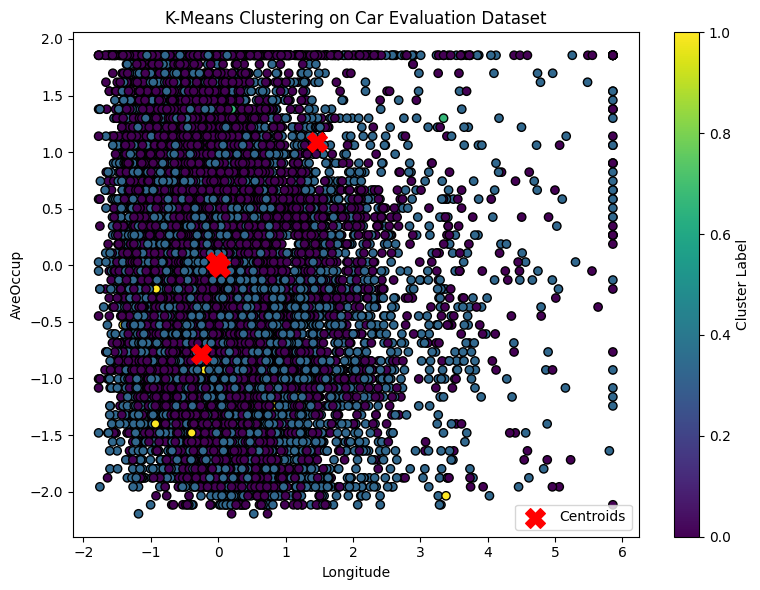

Saved: Exp03\K-mean-Cluster\kmeans_clusters.pdf


In [113]:
# 7. Plot K-Means clusters using first two features for visualization
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap="viridis",
    edgecolor="k"
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker="X",
    c="red",
    label="Centroids"
)

plt.title("K-Means Clustering on Car Evaluation Dataset")
plt.xlabel(feature_names[7])
plt.ylabel(feature_names[5])
plt.colorbar(label="Cluster Label")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kmeans_clusters.pdf", dpi=300)
plt.show()

print(f"Saved: {OUTPUT_DIR / 'kmeans_clusters.pdf'}")

In [114]:
accuracy = accuracy_score(y, predicted_labels)
sil_score = silhouette_score(X_scaled, clusters)

In [115]:
print(accuracy)
print(sil_score)

0.04689922480620155
0.33546908993141816


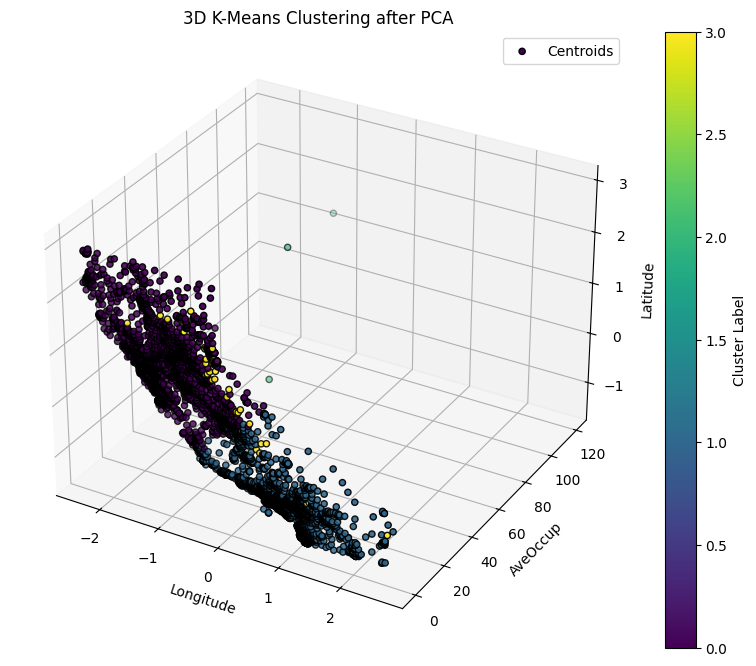

In [111]:
# plot 3D
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# 3D Figure
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

# 3D Scatter Plot
scatter = ax.scatter(
    X_scaled[:, 7],
    X_scaled[:, 5],
    X_scaled[:, 6],
    c=clusters,
    cmap='viridis',
    edgecolor='k',
    label="Centroids"
)

# Labels
ax.set_xlabel(feature_names[7])
ax.set_ylabel(feature_names[5])
ax.set_zlabel(feature_names[6])

ax.set_title('3D K-Means Clustering after PCA')

# Colorbar
plt.colorbar(scatter, label='Cluster Label')
plt.legend()
plt.savefig(OUTPUT_DIR / "kmeans_clusters_3d.pdf")
plt.show()

In [116]:
# Majority Cluster Mapping
def majority_cluster_map(cluster_ids, y_true):
    mapping = {}

    for cluster in np.unique(cluster_ids):
        mask = cluster_ids == cluster
        true_labels = y_true[mask]
        majority_label = pd.Series(true_labels).value_counts().idxmax()
        mapping[cluster] = majority_label

    return mapping
# Example usage:
cluster_ids = np.array([0, 0, 1, 1, 2, 2])
y_true = np.array([0, 0, 1, 1, 2, 2])
mapping = majority_cluster_map(cluster_ids, y_true)
print(mapping)  # Output: {0: 0, 1: 1, 2: 2}




{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [117]:
# Cluster-to-Class Mapping
def apply_cluster_map(cluster_ids, mapping):
    return np.array([mapping[c] for c in cluster_ids])

# Example usage:
predicted_labels = apply_cluster_map(cluster_ids, mapping)
print(predicted_labels)  # Output: [0, 0, 1, 1, 2, 2]

[0 0 1 1 2 2]
